In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from testgen.analysis_utils import *
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import MultiLabelBinarizer

In [2]:
# read results file
base_path = Path().cwd()
results_path = base_path / "results"
data_path = base_path / "data"

In [3]:
sensors_df = pd.read_excel(data_path / "sensor_requirements.xlsx")
actuators_df = pd.read_excel(data_path / "actuator_requirements.xlsx")
actuators_df.columns = ["requirement"]

In [4]:
labels = get_sensors_labels()
labels

{'acceleration_pedal': 'Acc',
 'wheel_steering_angle': 'WSA',
 'wheel_speed': 'WS',
 'yaw_rate': 'YR',
 'steering_torque': 'ST'}

# Sensors Analysis

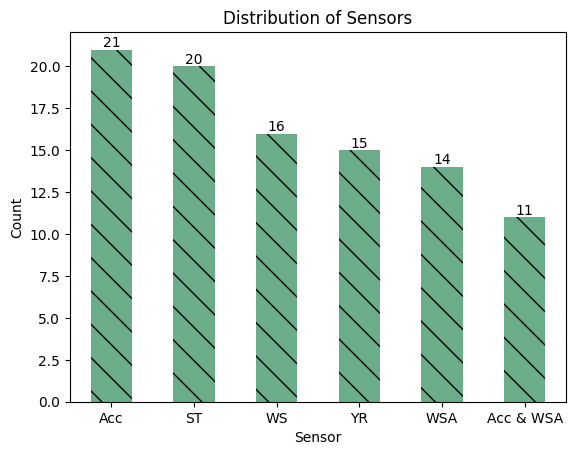

In [5]:
def get_sensor_name(row):
    sensor_names = []
    for i in range(1, len(row)):
        if row[i] == 1:
            sensor_names.append(sensors_df.columns[i])
    return " & ".join([labels[x] for x in sensor_names])

ax = sensors_df.apply(get_sensor_name, axis=1).value_counts().plot.bar(
    title="Distribution of Sensors",
    color="seagreen",
    alpha=0.7,
    hatch="\\",
)

_ = ax.bar_label(ax.containers[0])

ax.set_xlabel("Sensor")
ax.set_ylabel("Count")
plt.xticks(rotation=0)

# plt.savefig(
#     "figures/requirements_by_sensor.png",
#     bbox_inches="tight",
#     dpi=300,
# )

plt.show()

# Actuator Analysis

In [6]:
sensors_df_t = sensors_df[["requirement"]].copy()
sensors_df_t.insert(1, "is_actuator", 0)

actuators_df_t = actuators_df[["requirement"]].copy()
actuators_df_t.insert(1, "is_actuator", 1)

df = pd.concat([actuators_df_t, sensors_df_t])

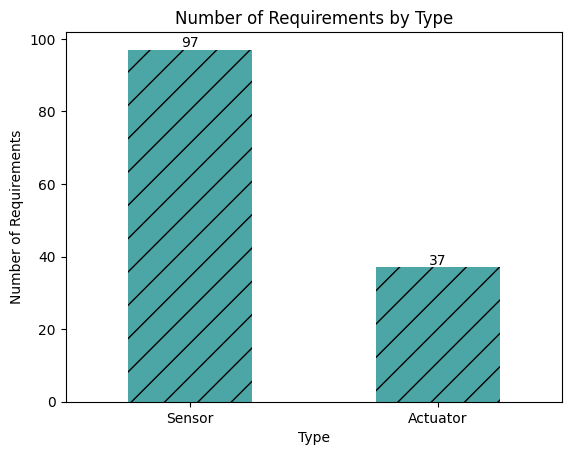

In [7]:
ax = df["is_actuator"].value_counts().plot(kind="bar", color="teal", alpha=0.7, hatch="/")
_ = ax.bar_label(ax.containers[0])

ax.set_xticklabels(["Sensor", "Actuator"], rotation=0)
ax.set_ylabel("Number of Requirements")
ax.set_xlabel("Type")
ax.set_title("Number of Requirements by Type")

# plt.savefig("figures/requirements_by_type.png", dpi=300, bbox_inches="tight")
plt.show()

# Actuator vs Sensor

In [8]:
actuator_available_results, actuator_results_single = get_best_results(
    results_path, "sensor-actuator*.json"
)

In [9]:
actuator_stats_df, actuator_responses_df = result_to_actuator_df(actuator_available_results)
actuator_stats_df["accuracy"] = (actuator_stats_df["accuracy"] *100).round(1)

In [10]:
actuator_responses_scores_df = pd.DataFrame(
    columns=["Model", "Number of Examples", "Acc", "F1"]
)
for g in actuator_responses_df[
    ["model", "number_of_examples", "true_target_sensor", "pred_target_sensor"]
].groupby(["model", "number_of_examples"]):

    g[1]["true_target_sensor"] = g[1]["true_target_sensor"].replace(
        {0: False, 1: True, "": False}
    )
    g[1]["pred_target_sensor"] = g[1]["pred_target_sensor"].replace(
        {0: False, 1: True, "": False}
    )

    acc = round(
        accuracy_score(g[1]["true_target_sensor"], g[1]["pred_target_sensor"]) * 100, 1
    )
    f1_ = round(
        f1_score(g[1]["true_target_sensor"], g[1]["pred_target_sensor"], average='macro') * 100, 1
    )

    actuator_responses_scores_df.loc[actuator_responses_scores_df.shape[0]] = [
        g[0][0],
        g[0][1].tolist(),
        acc,
        f1_,
    ]

# actuator_responses_scores_df.to_clipboard(index=False, header=True, sep=",")

actuator_responses_scores_df

,Model,Number of Examples,Acc,F1
0,gpt-4o,1,90.3,88.0
1,gpt-4o,3,86.6,84.0
2,gpt-4o,5,85.1,82.7
3,gpt-4o-mini,1,77.6,75.4
4,gpt-4o-mini,3,68.7,67.4
5,gpt-4o-mini,5,70.1,68.3
6,llama-3-70b,1,86.6,80.2
7,llama-3-70b,3,85.8,82.4
8,llama-3-70b,5,79.9,77.5
9,phi4-14b,1,70.9,69.5


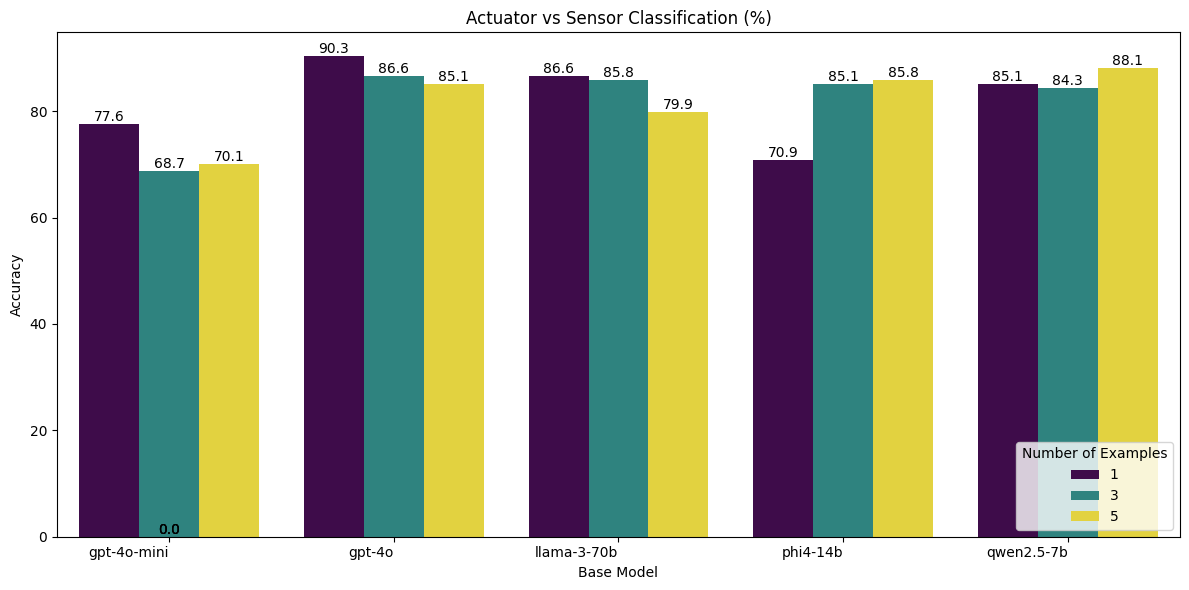

In [11]:
# Create the grouped bar plot using Seaborn
plt.figure(figsize=(12, 6))  # Adjust figure size for better readability
ax = sns.barplot(
    x="model",
    y="accuracy",
    hue="number_of_examples",
    data=actuator_stats_df,
    palette="viridis",
)

# Add data labels
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), ".1f"),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=10,
    )

# Add title and labels
plt.title("Actuator vs Sensor Classification (%)")
plt.xlabel("Base Model")
plt.ylabel("Accuracy")

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=0, ha="right")

# fix legend in lower right corner
plt.legend(
    title="Number of Examples",
    loc="lower right",
    fontsize=10,
    title_fontsize=10,
)

# Display the plot
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

# Single Analysis

In [12]:
single_available_results, single_results_single = get_best_results(
    results_path, "sensor_single*.json"
)

In [13]:
single_stats_df, single_responses_df, single_mismatch_stats_df = result_to_sensor_df(single_available_results)
single_stats_df["accuracy"] = (single_stats_df["accuracy"] *100).round(1)

In [14]:
single_responses_scores_df = pd.DataFrame(
    columns=["Model", "Number of Examples", "Acc", "F1"]
)
for g in single_responses_df[
    ["model", "number_of_examples", "true_target_sensor", "pred_target_sensor"]
].groupby(["model", "number_of_examples"]):

    # Initialize MultiLabelBinarizer
    mlb = MultiLabelBinarizer()

    # Fit and transform the true and predicted target sensors
    y_true = mlb.fit_transform(g[1]["true_target_sensor"])
    y_pred = mlb.transform(g[1]["pred_target_sensor"])

    acc = round(accuracy_score(y_true, y_pred) * 100, 1)
    f1_ = round(f1_score(y_true, y_pred, average='macro') * 100, 1)

    single_responses_scores_df.loc[single_responses_scores_df.shape[0]] = [
        g[0][0],
        g[0][1].tolist(),
        acc,
        f1_,
    ]

# single_responses_scores_df.to_clipboard(index=False, header=True, sep=",")

single_responses_scores_df

,Model,Number of Examples,Acc,F1
0,gpt-4o,1,94.8,97.0
1,gpt-4o,3,94.8,95.8
2,gpt-4o,5,95.9,96.7
3,gpt-4o,8,95.9,97.5
4,gpt-4o-mini,1,81.4,91.0
5,gpt-4o-mini,3,78.4,87.8
6,gpt-4o-mini,5,82.5,89.7
7,gpt-4o-mini,8,80.4,89.2
8,llama-3-70b,1,91.8,95.2
9,llama-3-70b,3,90.7,95.1


In [15]:
# try to export multirow and multicolumn in latex
# single_responses_scores_df = (
#     single_responses_scores_df
#         .sort_values(["Number of Examples", "Model"])
#         .set_index(["Number of Examples", "Model"])
# )

# single_responses_scores_df = single_responses_scores_df.unstack(level=0).swaplevel(axis=1).sort_index(axis=1)

# single_responses_scores_df.to_latex(
#     "tables/single_stats.tex",
#     index=True,
#     multicolumn=True,
#     multirow=True,
#     float_format="%.1f",
#     column_format="llcc",
#     escape=True,
#     caption="Single Sensor Model Accuracy (\%)",
#     label="tab:single_stats",
# )

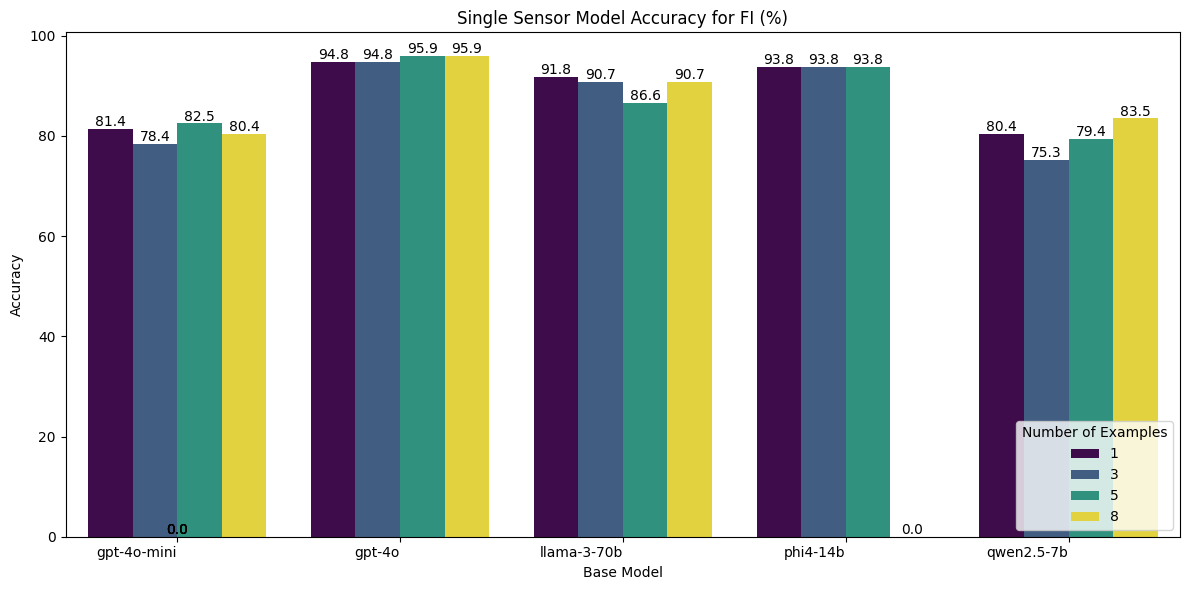

In [16]:
# Create the grouped bar plot using Seaborn
plt.figure(figsize=(12, 6))  # Adjust figure size for better readability
ax = sns.barplot(
    x="model", y="accuracy", hue="number_of_examples", data=single_stats_df, palette="viridis"
)

# Add data labels
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), ".1f"),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=10,
    )

# Add title and labels
plt.title("Single Sensor Model Accuracy for FI (%)")
plt.xlabel("Base Model")
plt.ylabel("Accuracy")

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=0, ha="right")

# fix legend in lower right corner
plt.legend(
    title="Number of Examples",
    loc="lower right",
    fontsize=10,
    title_fontsize=10,
)

# Display the plot
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

In [17]:
# # table outlining the accuracy of each model and number of examples
# single_stats_df_latex = single_stats_df.copy().sort_values(by=["accuracy"], ascending=False)
# single_stats_df_latex = single_stats_df_latex.reset_index(drop=True)
# single_stats_df_latex = single_stats_df_latex.rename(
#     columns={
#         "model": "Model",
#         "accuracy": "Accuracy (%)",
#         "number_of_examples": "Number of Examples"
#     }
# )
# single_stats_df_latex = single_stats_df_latex[["Model", "Accuracy (%)", "Number of Examples"]]

# single_stats_df_latex = single_stats_df_latex.pivot(
#     index="Model", columns="Number of Examples", values="Accuracy (%)"
# )

# single_stats_df_latex.to_latex(
#     "tables/single_stats.tex",
#     index=True,
#     multicolumn=False,
#     float_format="%.1f",
#     column_format="lccc",
#     escape=True,
#     caption="Single Sensor Model Accuracy (%)",
#     label="tab:single_stats",
# )

In [18]:
# # Create the grouped bar plot using Seaborn
# plt.figure(figsize=(12, 6))  # Adjust figure size for better readability
# ax = sns.barplot(
#     x="model",
#     y="total_tokens",
#     hue="number_of_examples",
#     data=stats_df,
#     palette="viridis",
# )

# # Add data labels
# for p in ax.patches:
#     ax.annotate(
#         format(p.get_height(), ",.0f"),
#         (p.get_x() + p.get_width() / 2.0, p.get_height()),
#         ha="center",
#         va="center",
#         xytext=(0, 5),
#         textcoords="offset points",
#         fontsize=10,
#     )

# # Add title and labels
# plt.title("Single Sensor Model Total Token Usage for FI")
# plt.xlabel("Base Model")
# plt.ylabel("Accuracy")

# # Rotate x-axis labels for better readability if needed
# plt.xticks(rotation=0, ha="right")

# # fix legend in lower right corner
# plt.legend(
#     title="Number of Examples",
#     loc="lower right",
#     fontsize=10,
#     title_fontsize=10,
# )

# # Display the plot
# plt.tight_layout()  # Adjust layout to prevent labels from overlapping
# plt.show()

In [19]:
def replace_and_join(values, labels):
    return " & ".join([labels.get(value) for value in values])


single_responses_df["pred_target_sensor_str"] = single_responses_df["pred_target_sensor"].apply(
    lambda x: replace_and_join(x, labels)
)
single_responses_df["true_target_sensor_str"] = single_responses_df["true_target_sensor"].apply(
    lambda x: replace_and_join(x, labels)
)

In [20]:
scores_df = calc_scores(single_responses_df)

scores_df

,model,number_of_examples,accuracy,precision,recall,f1
sensor,,,,,,
All,gpt-4o-mini,1,0.81,0.83,0.98,0.89
Acc,gpt-4o-mini,1,1.00,1.00,1.00,1.00
Acc & WSA,gpt-4o-mini,1,0.92,1.00,0.92,0.96
ST,gpt-4o-mini,1,1.00,1.00,1.00,1.00
WS,gpt-4o-mini,1,1.00,1.00,1.00,1.00
...,...,...,...,...,...,...
Acc & WSA,qwen2.5-7b,8,0.88,1.00,0.88,0.93
ST,qwen2.5-7b,8,1.00,1.00,1.00,1.00
WS,qwen2.5-7b,8,1.00,1.00,1.00,1.00


# Batch Analysis

In [21]:
batch_available_results, batch_results_single = get_best_results(
    results_path, "sensor_bulk*.json"
)

In [22]:
batch_stats_df, batch_responses_df, batch_mismatch_stats_df = result_to_sensor_df(batch_available_results)
batch_stats_df["accuracy"] = (batch_stats_df["accuracy"] *100).round(1)

In [23]:
batch_responses_scores_df = pd.DataFrame(
    columns=["Model", "Batch Size", "Number of Examples", "Acc", "F1"]
)
for g in batch_responses_df[
    ["model", "batch_size", "number_of_examples", "true_target_sensor", "pred_target_sensor"]
].groupby(["model", "batch_size", "number_of_examples"]):

    # Initialize MultiLabelBinarizer
    mlb = MultiLabelBinarizer()

    # Fit and transform the true and predicted target sensors
    y_true = mlb.fit_transform(g[1]["true_target_sensor"])
    y_pred = mlb.transform(g[1]["pred_target_sensor"])

    acc = round(accuracy_score(y_true, y_pred) * 100, 1)
    f1_ = round(f1_score(y_true, y_pred, average='macro') * 100, 1)

    batch_responses_scores_df.loc[batch_responses_scores_df.shape[0]] = [
        g[0][0],
        g[0][1].tolist(),
        g[0][2].tolist(),
        acc,
        f1_,
    ]

# batch_responses_scores_df.to_clipboard(index=False, header=True, sep=",")

batch_responses_scores_df

,Model,Batch Size,Number of Examples,Acc,F1
0,gpt-4o,2,1,92.7,95.4
1,gpt-4o,2,3,93.8,95.6
2,gpt-4o,2,5,95.8,97.2
3,gpt-4o,2,8,93.8,95.2
4,gpt-4o,3,1,95.8,97.5
5,gpt-4o,3,3,95.8,97.0
6,gpt-4o,3,5,95.8,97.2
7,gpt-4o,3,8,94.8,96.4
8,gpt-4o,5,1,92.6,95.4
9,gpt-4o,5,3,93.7,96.5


In [24]:
# table outlining the accuracy of each model and number of examples
for bs in batch_stats_df["batch_size"].unique():

    batch_stats_df_latex = batch_stats_df.loc[batch_stats_df["batch_size"] == bs].copy()
    batch_stats_df_latex = batch_stats_df_latex.rename(
        columns={
            "model": "Model",
            "accuracy": "Accuracy (%)",
            "number_of_examples": "Number of Examples",
        }
    )
    batch_stats_df_latex = batch_stats_df_latex[["Model", "Accuracy (%)", "Number of Examples"]]

    batch_stats_df_latex = batch_stats_df_latex.pivot(
        index="Model", columns="Number of Examples", values="Accuracy (%)"
    )

    # batch_stats_df_latex.to_latex(
    #     f"tables/batch_{bs}_stats.tex",
    #     index=True,
    #     multicolumn=False,
    #     float_format="%.1f",
    #     column_format="lccc",
    #     escape=True,
    #     label=f"tab:batch_{bs}_stats",
    # )

# Dropped Analysis

In [25]:
dropped_available_results, dropped_results_single = get_best_results(
    results_path, "sensor_dropped*.json"
)

In [26]:
dropped_stats_df, dropped_responses_df, dropped_mismatch_stats_df = result_to_sensor_df(dropped_available_results)
dropped_stats_df["accuracy"] = (dropped_stats_df["accuracy"] *100).round(1)

In [27]:
dropped_responses_scores_df = pd.DataFrame(
    columns=["Model", "Number of Examples", "Acc", "F1"]
)
for g in dropped_responses_df[
    ["model", "number_of_examples", "true_target_sensor", "pred_target_sensor"]
].groupby(["model", "number_of_examples"]):

    # Initialize MultiLabelBinarizer
    mlb = MultiLabelBinarizer()

    # Fit and transform the true and predicted target sensors
    y_true = mlb.fit_transform(g[1]["true_target_sensor"])
    y_pred = mlb.transform(g[1]["pred_target_sensor"])

    acc = round(accuracy_score(y_true, y_pred) * 100, 1)
    f1_ = round(f1_score(y_true, y_pred, average='micro') * 100, 1)

    dropped_responses_scores_df.loc[dropped_responses_scores_df.shape[0]] = [
        g[0][0],
        g[0][1].tolist(),
        acc,
        f1_,
    ]

# dropped_responses_scores_df.to_clipboard(index=False, header=True, sep=",")

dropped_responses_scores_df

,Model,Number of Examples,Acc,F1
0,gpt-4o,1,93.8,93.9
1,gpt-4o,3,91.8,92.5
2,gpt-4o,5,94.8,96.1
3,gpt-4o,8,92.8,94.7
4,gpt-4o-mini,1,93.8,94.5
5,gpt-4o-mini,3,95.9,96.8
6,gpt-4o-mini,5,92.8,94.5
7,gpt-4o-mini,8,89.7,92.2
8,llama-3-70b,1,91.8,92.6
9,llama-3-70b,3,83.5,86.3


In [28]:
# table outlining the accuracy of each model and number of examples
dropped_stats_df_latex = dropped_stats_df.copy()
dropped_stats_df_latex = dropped_stats_df_latex.rename(
    columns={
        "model": "Model",
        "accuracy": "Accuracy (%)",
        "number_of_examples": "Number of Examples"
    }
)
dropped_stats_df_latex = dropped_stats_df_latex[["Model", "Accuracy (%)", "Number of Examples"]]

dropped_stats_df_latex = dropped_stats_df_latex.pivot(
    index="Model", columns="Number of Examples", values="Accuracy (%)"
)

# dropped_stats_df_latex.to_latex(
#     "tables/dropped_stats.tex",
#     index=True,
#     multicolumn=False,
#     float_format="%.1f",
#     column_format="lcccc",
#     escape=True,
#     caption="Dropped Sensor (Single) Model Accuracy (%)",
#     label="tab:dropped_stats",
# )